# Flights Analytics
---

## 0. Configuración

In [43]:
# ── Dependencias ────────────────────────────────────────────────────────────
import json
import warnings
warnings.filterwarnings("ignore")

import boto3
import pandas as pd
import awswrangler as wr
from sqlalchemy import create_engine, text

import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
from scipy import stats

from statsforecast import StatsForecast
from statsforecast.models import AutoETS, AutoARIMA, AutoTheta

# Visualizaciones
from plotnine import (
    ggplot, aes,
    geom_bar, geom_col, geom_line, geom_point, geom_text,
    geom_errorbar, geom_hline, geom_abline, geom_ribbon, geom_vline,
    coord_flip, scale_fill_manual, scale_color_manual,
    labs, theme, theme_minimal, theme_void,
    element_text, element_blank, element_rect, element_line,
    scale_x_continuous, scale_y_continuous, scale_x_datetime,
    position_stack, facet_wrap, annotate
)
from great_tables import GT, style, loc, nanoplot_options

print("Librerías cargadas")


Librerías cargadas


### 0.1 Conexión a la Read Replica

Las credenciales se obtienen desde **AWS Secrets Manager**. 
Conectamos al **endpoint de la Read Replica**.

In [2]:
# ── Parámetros ───────────────────────────────────────────────────────────────
SECRET_ID    = "itam/rds/flights/credentials"
RDS_REPLICA  = "itam-flights-replica-433956820129.cer2ok0gohrq.us-east-1.rds.amazonaws.com"
REGION       = "us-east-1"

# ── Obtener credenciales desde Secrets Manager ───────────────────────────────
client = boto3.client("secretsmanager", region_name=REGION)
secret = client.get_secret_value(SecretId=SECRET_ID)
creds  = json.loads(secret["SecretString"])

# ── Engine SQLAlchemy 2.0 apuntando a la Read Replica ────────────────────────
engine = create_engine(
    f"postgresql+psycopg2://{creds['username']}:{creds['password']}"
    f"@{RDS_REPLICA}:{creds['port']}/{creds['dbname']}",
    pool_pre_ping=True,
)

# ── Verificar conexión ───────────────────────────────────────────────────────
with engine.connect() as conn:
    conn.execute(text("SELECT 1"))

print(f"Conexión exitosa: {RDS_REPLICA} / {creds['dbname']}")


Conexión exitosa: itam-flights-replica-433956820129.cer2ok0gohrq.us-east-1.rds.amazonaws.com / flights


### 0.2 Paleta de colores compartida

In [3]:
# Paleta consistente para todas las visualizaciones del notebook
PALETTE = {
    "blue_dark":  "#1B3A6B",
    "blue_mid":   "#2563EB",
    "blue_light": "#93C5FD",
    "red":        "#DC2626",
    "orange":     "#F59E0B",
    "green":      "#16A34A",
    "gray":       "#6B7280",
    "bg":         "#F8FAFC",
}

BASE_THEME = (
    theme_minimal()
    + theme(
        plot_background  = element_rect(fill=PALETTE["bg"], color=None),
        panel_background = element_rect(fill=PALETTE["bg"], color=None),
        panel_grid_major = element_line(color="#E2E8F0"),
        panel_grid_minor = element_blank(),
        axis_text        = element_text(size=9,  color="#374151"),
        axis_title       = element_text(size=10, color="#1F2937", face="bold"),
        plot_title       = element_text(size=13, color=PALETTE["blue_dark"], face="bold"),
        plot_subtitle    = element_text(size=9,  color=PALETTE["gray"]),
    )
)
print("Tema base configurado")


Tema base configurado


## 1. Consultas desde RDS
---

### P1 · Rutas más frecuentes
**¿Cuáles son las 10 rutas origen-destino con más vuelos?**

In [4]:
SQL_P1 = """
SELECT
    f.origin_airport,
    f.destination_airport,
    a.city  AS origin_city,
    a2.city AS destination_city,
    COUNT(*) AS total_flights
FROM flights f
JOIN airports a  ON f.origin_airport      = a.iata_code
JOIN airports a2 ON f.destination_airport = a2.iata_code
GROUP BY f.origin_airport, f.destination_airport, a.city, a2.city
ORDER BY total_flights DESC
LIMIT 10;
"""

with engine.connect() as conn:
    df_p1 = pd.read_sql(text(SQL_P1), conn)

df_p1["route"] = df_p1["origin_airport"] + " → " + df_p1["destination_airport"]
df_p1["route_label"] = df_p1["origin_city"] + " → " + df_p1["destination_city"]
df_p1 = df_p1.sort_values("total_flights")          # ascendente para coord_flip

df_p1["route_label"] = pd.Categorical(
    df_p1["route_label"],
    categories=df_p1["route_label"].tolist(),
    ordered=True,
)

df_p1


,origin_airport,destination_airport,origin_city,destination_city,total_flights,route,route_label
9,OGG,HNL,Kahului,Honolulu,873,OGG → HNL,Kahului → Honolulu
8,HNL,OGG,Honolulu,Kahului,874,HNL → OGG,Honolulu → Kahului
7,ORD,LGA,Chicago,New York,908,ORD → LGA,Chicago → New York
6,LGA,ORD,New York,Chicago,917,LGA → ORD,New York → Chicago
5,LAX,LAS,Los Angeles,Las Vegas,987,LAX → LAS,Los Angeles → Las Vegas
4,LAS,LAX,Las Vegas,Los Angeles,1018,LAS → LAX,Las Vegas → Los Angeles
3,LAX,SFO,Los Angeles,San Francisco,1172,LAX → SFO,Los Angeles → San Francisco
2,SFO,LAX,San Francisco,Los Angeles,1186,SFO → LAX,San Francisco → Los Angeles
1,JFK,LAX,New York,Los Angeles,1217,JFK → LAX,New York → Los Angeles
0,LAX,JFK,Los Angeles,New York,1218,LAX → JFK,Los Angeles → New York


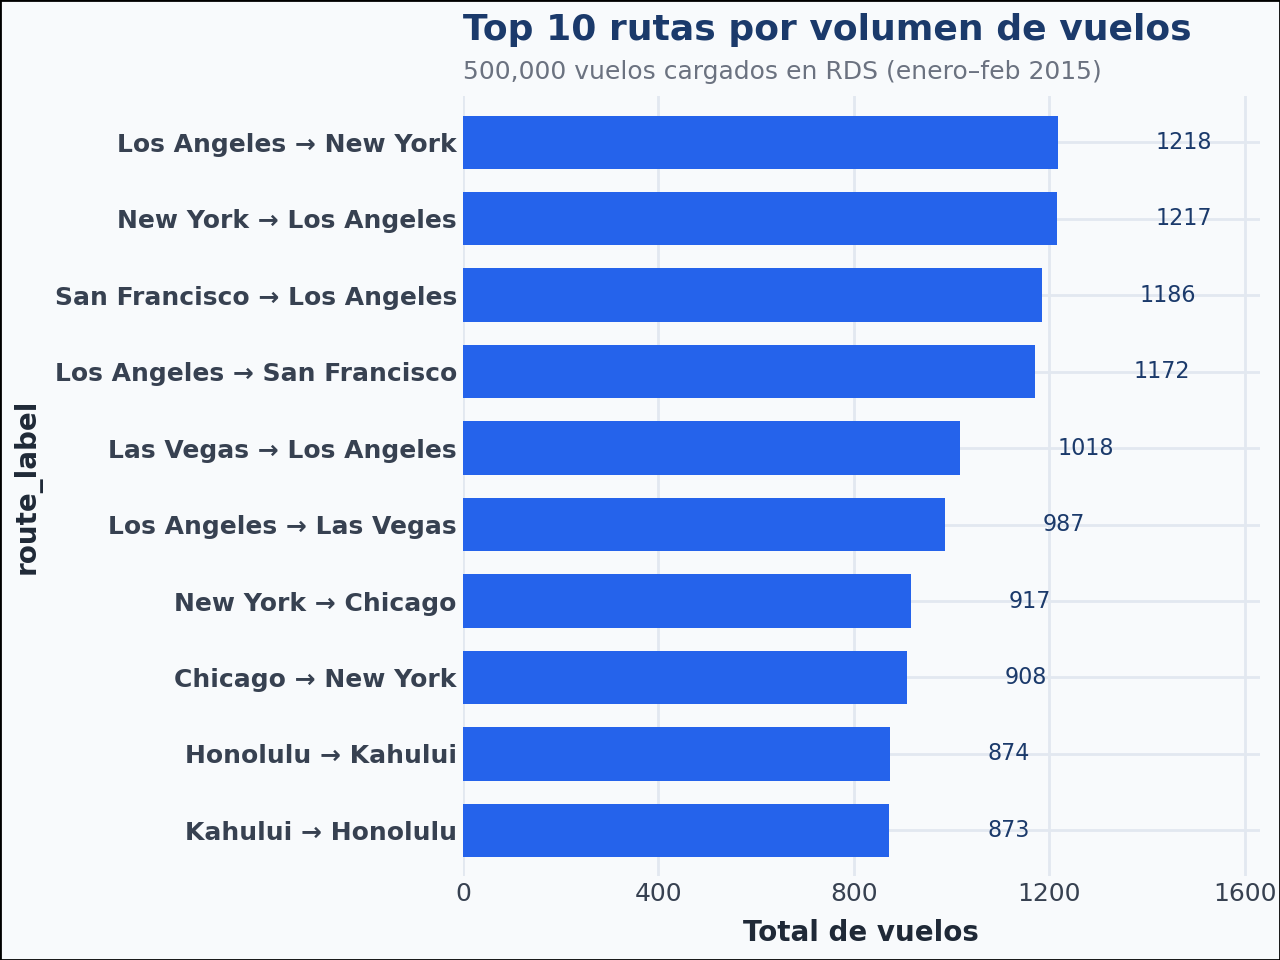

In [5]:
(
    ggplot(df_p1, aes(x="route_label", y="total_flights"))
    + geom_col(fill=PALETTE["blue_mid"], width=0.7)
    + geom_text(
        aes(label="total_flights"),
        ha="left", nudge_y=200, size=8, color=PALETTE["blue_dark"],
    )
    + coord_flip()
    + scale_y_continuous(expand=(0, 0, 0.15, 0))
    + labs(
        title="Top 10 rutas por volumen de vuelos",
        subtitle="500,000 vuelos cargados en RDS (enero–feb 2015)",
        x=None, y="Total de vuelos",
    )
    + BASE_THEME
    + theme(axis_text_y=element_text(size=9, face="bold"))
)


---
### P2 · Aerolíneas con mayor tasa de cancelación
**¿Cuáles son las 5 aerolíneas con mayor porcentaje de vuelos cancelados?**

In [6]:
SQL_P2 = """
SELECT
    f.airline                                                   AS iata_code,
    a.airline                                                   AS airline_name,
    COUNT(*)                                                    AS total_flights,
    SUM(f.cancelled::int)                                       AS flights_cancelled,
    ROUND(SUM(f.cancelled::int)::numeric / COUNT(*), 4)        AS pct_cancelled
FROM flights f
JOIN airlines a ON f.airline = a.iata_code
GROUP BY f.airline, a.airline
ORDER BY pct_cancelled DESC
LIMIT 5;
"""

with engine.connect() as conn:
    df_p2 = pd.read_sql(text(SQL_P2), conn)

df_p2["pct_label"] = (df_p2["pct_cancelled"] * 100).round(1).astype(str) + "%"
df_p2 = df_p2.sort_values("pct_cancelled")

df_p2["airline_name"] = pd.Categorical(
    df_p2["airline_name"],
    categories=df_p2["airline_name"].tolist(),
    ordered=True,
)

df_p2


,iata_code,airline_name,total_flights,flights_cancelled,pct_cancelled,pct_label
4,UA,United Air Lines Inc.,40873,1424,0.0348,3.5%
3,US,US Airways Inc.,35591,1268,0.0356,3.6%
2,EV,Atlantic Southeast Airlines,52965,2523,0.0476,4.8%
1,B6,JetBlue Airways,23062,1479,0.0641,6.4%
0,MQ,American Eagle Airlines Inc.,31896,3136,0.0983,9.8%


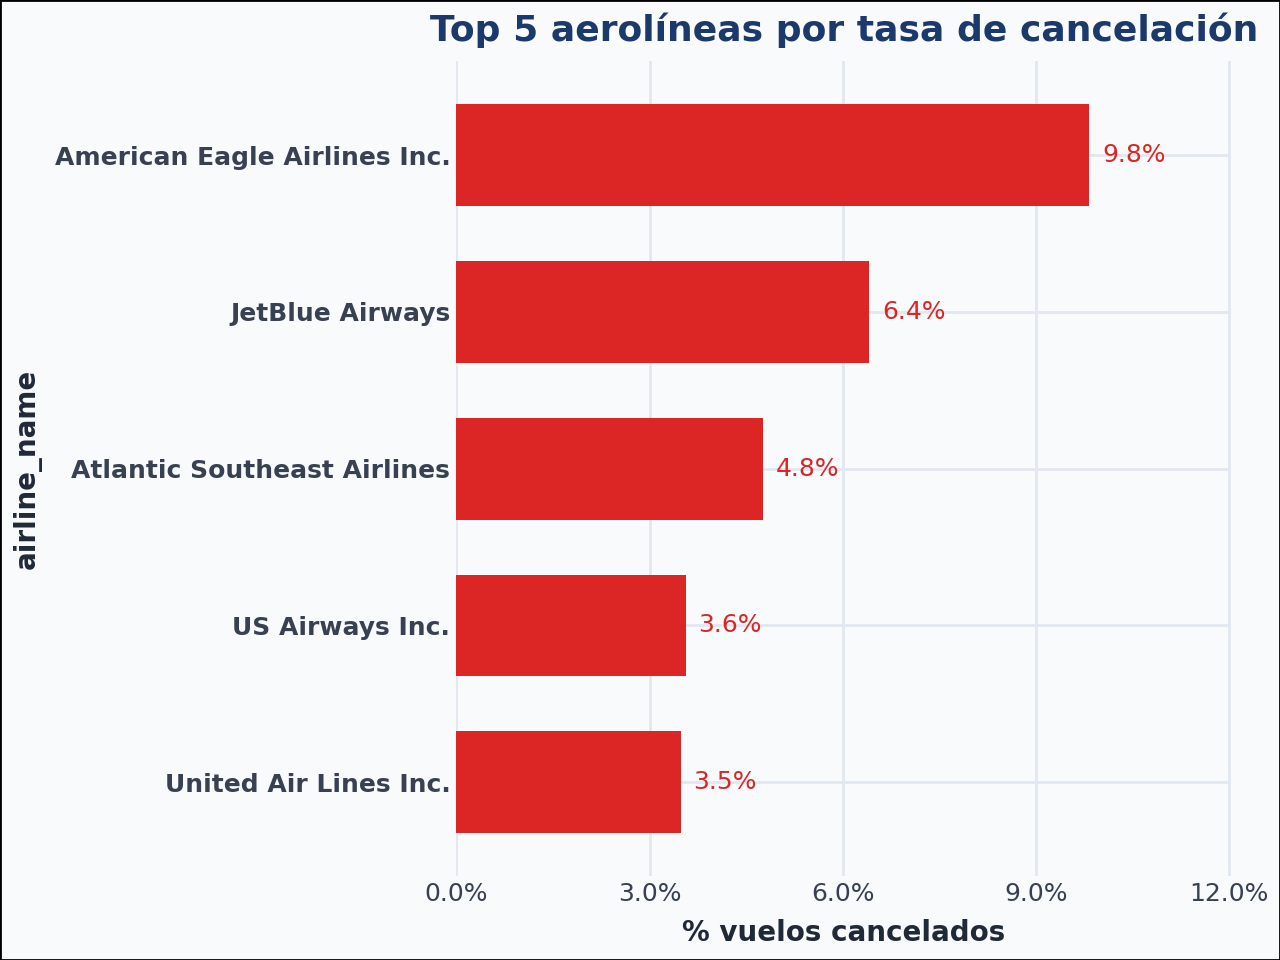

In [7]:
(
    ggplot(df_p2, aes(x="airline_name", y="pct_cancelled"))
    + geom_col(fill=PALETTE["red"], width=0.65)
    + geom_text(
        aes(label="pct_label"),
        ha="left", nudge_y=0.002, size=9, color=PALETTE["red"],
    )
    + coord_flip()
    + scale_y_continuous(
        labels=lambda lst: [f"{v*100:.1f}%" for v in lst],
        expand=(0, 0, 0.2, 0),
    )
    + labs(
        title="Top 5 aerolíneas por tasa de cancelación",
        x=None, y="% vuelos cancelados",
    )
    + BASE_THEME
    + theme(axis_text_y=element_text(size=9, face="bold"))
)


---
### P3 · Distribución de razones de cancelación
**¿Cuántos vuelos fueron cancelados por cada razón?**

Los códigos del dataset son: **A** = Carrier · **B** = Weather · **C** = NAS · **D** = Security

In [8]:
SQL_P3 = """
SELECT
    f.cancellation_reason,
    COUNT(*) AS cancellations
FROM flights f
WHERE f.cancellation_reason IS NOT NULL
GROUP BY f.cancellation_reason
ORDER BY cancellations DESC;
"""

with engine.connect() as conn:
    df_p3 = pd.read_sql(text(SQL_P3), conn)

REASON_MAP = {"A": "Carrier", "B": "Weather", "C": "NAS", "D": "Security"}
df_p3["reason_label"] = df_p3["cancellation_reason"].map(REASON_MAP)
df_p3["pct"] = (df_p3["cancellations"] / df_p3["cancellations"].sum() * 100).round(1)

df_p3


,cancellation_reason,cancellations,reason_label,pct
0,B,10630,Weather,63.2
1,A,3230,Carrier,19.2
2,C,2962,NAS,17.6
3,D,2,Security,0.0


In [9]:
# great_tables — tabla formateada con barra de progreso inline
(
    GT(df_p3[["reason_label", "cancellations", "pct"]])
    .tab_header(
        title="Cancelaciones por razón",
        subtitle="Distribución sobre el total de vuelos cancelados",
    )
    .cols_label(
        reason_label="Razón",
        cancellations="Cancelaciones",
        pct="% del total",
    )
    .fmt_integer(columns="cancellations")
    .fmt_number(columns="pct", decimals=1, pattern="{x}%")
    .data_color(
        columns="cancellations",
        palette=["#DBEAFE", "#1B3A6B"],
    )
    .tab_style(
        style=style.text(weight="bold"),
        locations=loc.body(rows=[0]),
    )
    .tab_options(table_width="500px")
)


GT(_tbl_data=  reason_label  cancellations   pct
0      Weather          10630  63.2
1      Carrier           3230  19.2
2          NAS           2962  17.6
3     Security              2   0.0, _body=<great_tables._gt_data.Body object at 0x7f923d77c620>, _boxhead=Boxhead([ColInfo(var='reason_label', type=<ColInfoTypeEnum.default: 1>, column_label='Razón', column_align='left', column_width=None), ColInfo(var='cancellations', type=<ColInfoTypeEnum.default: 1>, column_label='Cancelaciones', column_align='right', column_width=None), ColInfo(var='pct', type=<ColInfoTypeEnum.default: 1>, column_label='% del total', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f923c5b0b00>, _spanners=Spanners([]), _heading=Heading(title='Cancelaciones por razón', subtitle='Distribución sobre el total de vuelos cancelados', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f923d589ee0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f923c5b33b0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='cancellations', rows=[0], mask=None), grpname=None, colname='cancellations', rownum=0, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#1b3a6b')]), StyleInfo(locname=LocBody(columns='cancellations', rows=[1], mask=None), grpname=None, colname='cancellations', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#a1b5d1')]), StyleInfo(locname=LocBody(columns='cancellations', rows=[2], mask=None), grpname=None, colname='cancellations', rownum=2, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#a6b9d5')]), StyleInfo(locname=LocBody(columns='cancellations', rows=[3], mask=None), grpname=None, colname='cancellations', rownum=3, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#dbeafe')]), StyleInfo(locname=LocBody(columns=None, rows=[0], mask=None), grpname=None, colname='reason_label', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=[0], mask=None), grpname=None, colname='cancellations', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=[0], mask=None), grpname=None, colname='pct', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7f923c5b38f0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f923d5f90d0>, <great_tables._gt_data.FormatInfo object at 0x7f923d5f82c0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='500px'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value=

---
### P4 · Retraso promedio de salida por mes
**¿Cómo varía el retraso promedio de salida a lo largo del año?**  
*(Solo vuelos no cancelados con departure_delay > 0)*

In [10]:
SQL_P4 = """
SELECT
    f.month,
    ROUND(AVG(f.departure_delay), 2) AS avg_delay
FROM flights f
WHERE f.cancelled = FALSE
  AND f.departure_delay > 0
GROUP BY f.month
ORDER BY f.month;
"""

with engine.connect() as conn:
    df_p4 = pd.read_sql(text(SQL_P4), conn)

MONTH_NAMES = {
    1:"Ene", 2:"Feb"
}
df_p4["month_name"] = df_p4["month"].map(MONTH_NAMES)

df_p4


,month,avg_delay,month_name
0,1,32.57,Ene
1,2,42.31,Feb


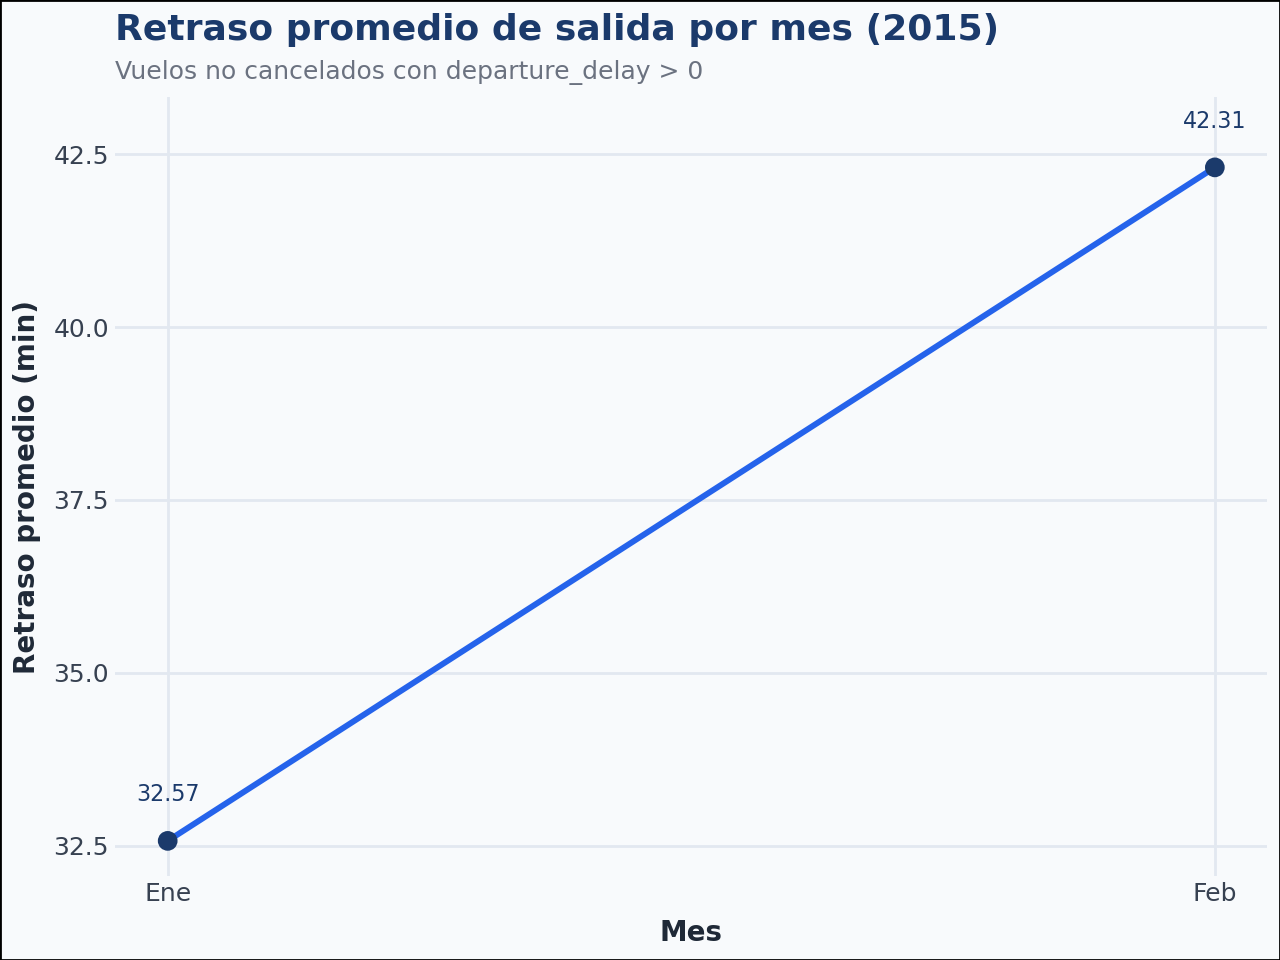

In [11]:
(
    ggplot(df_p4, aes(x="month", y="avg_delay"))
    + geom_line(color=PALETTE["blue_mid"], size=1.2)
    + geom_point(color=PALETTE["blue_dark"], size=3)
    + geom_text(
        aes(label="avg_delay"),
        va="bottom", nudge_y=0.5, size=8, color=PALETTE["blue_dark"],
    )
    + scale_x_continuous(breaks=list(range(1, 3)), labels=list(MONTH_NAMES.values()))
    + labs(
        title="Retraso promedio de salida por mes (2015)",
        subtitle="Vuelos no cancelados con departure_delay > 0",
        x="Mes", y="Retraso promedio (min)",
    )
    + BASE_THEME
)


---
### P5 · Aeropuertos con más minutos de retraso por clima
**¿Cuáles son los 10 aeropuertos de origen con mayor acumulado de minutos de retraso climático?**

In [12]:
SQL_P5 = """
SELECT
    a.airport,
    f.origin_airport,
    SUM(f.weather_delay) AS total_weather_delay
FROM flights f
JOIN airports a ON f.origin_airport = a.iata_code
WHERE f.weather_delay IS NOT NULL
GROUP BY a.airport, f.origin_airport
ORDER BY total_weather_delay DESC
LIMIT 10;
"""

with engine.connect() as conn:
    df_p5 = pd.read_sql(text(SQL_P5), conn)

df_p5["airport_label"] = df_p5["origin_airport"] + " – " + df_p5["airport"].str.slice(0, 30)
df_p5 = df_p5.sort_values("total_weather_delay")

df_p5["airport_label"] = pd.Categorical(
    df_p5["airport_label"],
    categories=df_p5["airport_label"].tolist(),
    ordered=True,
)

df_p5


,airport,origin_airport,total_weather_delay,airport_label
9,Dallas/Fort Worth International Airport,DFW,6870,DFW – Dallas/Fort Worth Internationa
8,Phoenix Sky Harbor International Airport,PHX,7878,PHX – Phoenix Sky Harbor Internation
7,Ronald Reagan Washington National Airport,DCA,8188,DCA – Ronald Reagan Washington Natio
6,Denver International Airport,DEN,8359,DEN – Denver International Airport
5,Gen. Edward Lawrence Logan International Airport,BOS,11361,BOS – Gen. Edward Lawrence Logan Int
4,Detroit Metropolitan Airport,DTW,12361,DTW – Detroit Metropolitan Airport
3,Hartsfield-Jackson Atlanta International Airport,ATL,12562,ATL – Hartsfield-Jackson Atlanta Int
2,LaGuardia Airport (Marine Air Terminal),LGA,13620,LGA – LaGuardia Airport (Marine Air
1,John F. Kennedy International Airport (New Yor...,JFK,20542,JFK – John F. Kennedy International
0,Chicago O'Hare International Airport,ORD,102749,ORD – Chicago O'Hare International A


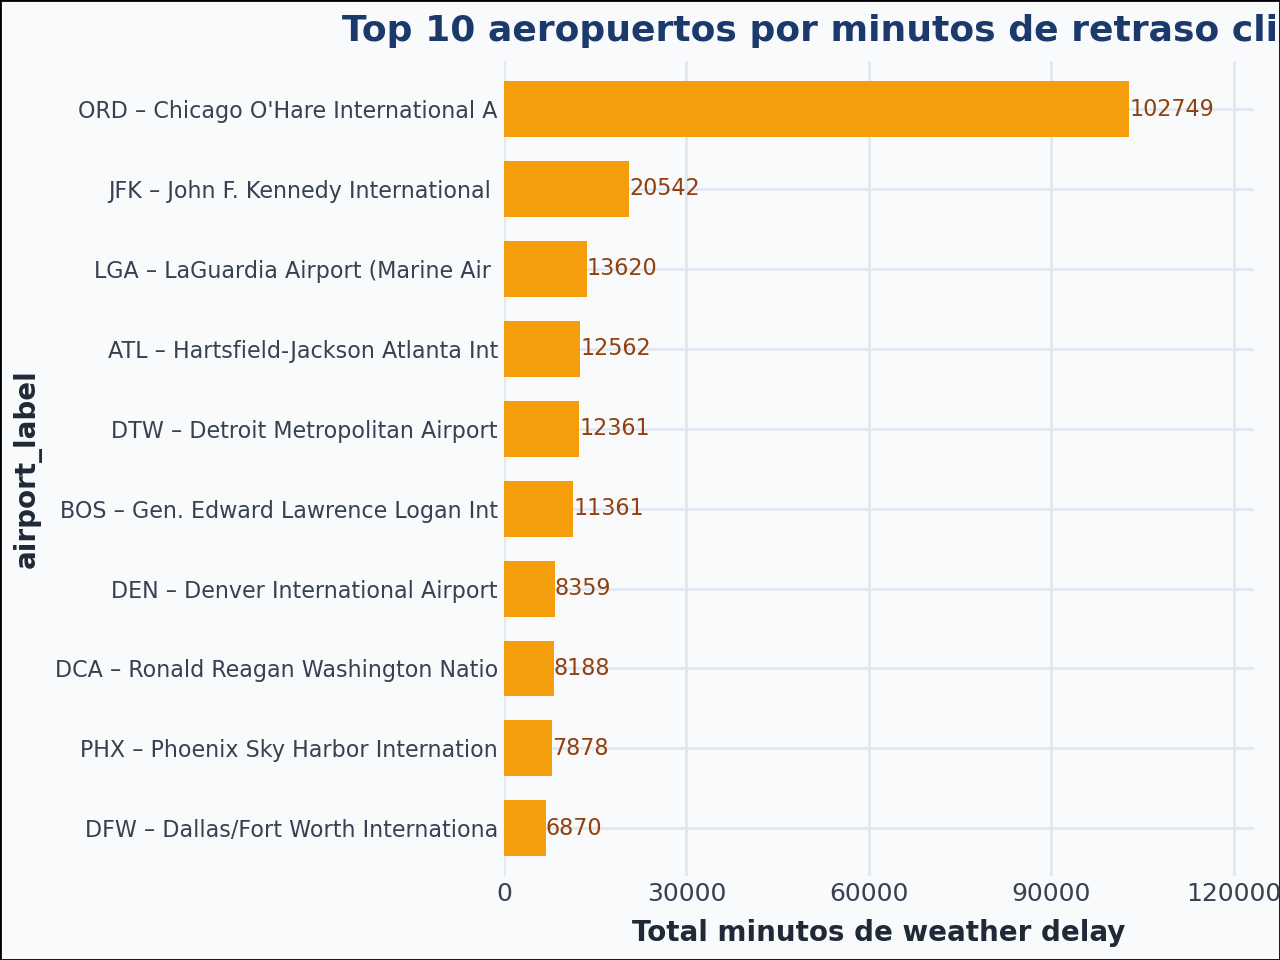

In [13]:
(
    ggplot(df_p5, aes(x="airport_label", y="total_weather_delay"))
    + geom_col(fill=PALETTE["orange"], width=0.7)
    + geom_text(
        aes(label="total_weather_delay"),
        ha="left", nudge_y=30, size=8, color="#92400E",
    )
    + coord_flip()
    + scale_y_continuous(expand=(0, 0, 0.2, 0))
    + labs(
        title="Top 10 aeropuertos por minutos de retraso climático",
        x=None, y="Total minutos de weather delay",
    )
    + BASE_THEME
    + theme(axis_text_y=element_text(size=8))
)


---
### W1 · Vuelo con mayor retraso de llegada por aerolínea
**Window function `RANK()` — el vuelo más retrasado de cada aerolínea.**

In [14]:
SQL_W1 = """
WITH RankedFlights AS (
    SELECT
        f.airline,
        f.flight_number,
        f.origin_airport,
        f.destination_airport,
        f.arrival_delay,
        RANK() OVER (
            PARTITION BY f.airline
            ORDER BY f.arrival_delay DESC NULLS LAST
        ) AS delay_rank
    FROM flights f
)
SELECT
    r.airline,
    r.flight_number,
    r.origin_airport,
    r.destination_airport,
    r.arrival_delay
FROM RankedFlights r
WHERE delay_rank = 1
ORDER BY arrival_delay DESC;
"""

with engine.connect() as conn:
    df_w1 = pd.read_sql(text(SQL_W1), conn)

df_w1["route"] = df_w1["origin_airport"] + " → " + df_w1["destination_airport"]

df_w1


,airline,flight_number,origin_airport,destination_airport,arrival_delay,route
0,AA,1322,BHM,DFW,1971,BHM → DFW
1,DL,1435,MIA,MSP,1174,MIA → MSP
2,HA,51,JFK,HNL,1013,JFK → HNL
3,OO,2642,CHO,ORD,953,CHO → ORD
4,UA,1443,ICT,DEN,863,ICT → DEN
5,MQ,2962,CLL,DFW,788,CLL → DFW
6,EV,2567,SHV,DFW,723,SHV → DFW
7,F9,1256,ORD,MIA,686,ORD → MIA
8,US,1782,SEA,CLT,621,SEA → CLT
9,WN,259,IAD,DEN,593,IAD → DEN


In [15]:
# great_tables — ranking con color degradado sobre arrival_delay
(
    GT(df_w1[["airline", "flight_number", "route", "arrival_delay"]])
    .tab_header(
        title="Vuelo con mayor retraso de llegada por aerolínea",
        subtitle="RANK() OVER (PARTITION BY airline ORDER BY arrival_delay DESC)",
    )
    .cols_label(
        airline="Aerolínea",
        flight_number="Vuelo #",
        route="Ruta",
        arrival_delay="Retraso llegada (min)",
    )
    .fmt_integer(columns=["flight_number", "arrival_delay"])
    .data_color(
        columns="arrival_delay",
        palette=["#FEF9C3", "#DC2626"],
    )
    .tab_style(
        style=style.text(weight="bold", color="black"),
        locations=loc.body(rows=[0]),
    )
    .tab_options(table_width="600px")
)


GT(_tbl_data=   airline  flight_number      route  arrival_delay
0       AA           1322  BHM → DFW           1971
1       DL           1435  MIA → MSP           1174
2       HA             51  JFK → HNL           1013
3       OO           2642  CHO → ORD            953
4       UA           1443  ICT → DEN            863
5       MQ           2962  CLL → DFW            788
6       EV           2567  SHV → DFW            723
7       F9           1256  ORD → MIA            686
8       US           1782  SEA → CLT            621
9       WN            259  IAD → DEN            593
10      NK            728  TPA → ORD            570
11      B6            576  MSY → JFK            502
12      AS            455  LAX → SEA            451
13      VX            731  DCA → DAL            384, _body=<great_tables._gt_data.Body object at 0x7f923c648dd0>, _boxhead=Boxhead([ColInfo(var='airline', type=<ColInfoTypeEnum.default: 1>, column_label='Aerolínea', column_align='left', column_width=None), ColInfo(var='flight_number', type=<ColInfoTypeEnum.default: 1>, column_label='Vuelo #', column_align='right', column_width=None), ColInfo(var='route', type=<ColInfoTypeEnum.default: 1>, column_label='Ruta', column_align='left', column_width=None), ColInfo(var='arrival_delay', type=<ColInfoTypeEnum.default: 1>, column_label='Retraso llegada (min)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f92366a7bc0>, _spanners=Spanners([]), _heading=Heading(title='Vuelo con mayor retraso de llegada por aerolínea', subtitle='RANK() OVER (PARTITION BY airline ORDER BY arrival_delay DESC)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f92366fcb60>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f92366fc350>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='arrival_delay', rows=[0], mask=None), grpname=None, colname='arrival_delay', rownum=0, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#dc2626')]), StyleInfo(locname=LocBody(columns='arrival_delay', rows=[1], mask=None), grpname=None, colname='arrival_delay', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#ed9075')]), StyleInfo(locname=LocBody(columns='arrival_delay', rows=[2], mask=None), grpname=None, colname='arrival_delay', rownum=2, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#f1a585')]), StyleInfo(locname=LocBody(columns='arrival_delay', rows=[3], mask=None), grpname=None, colname='arrival_delay', rownum=3, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#f2ad8b')]), StyleInfo(locname=LocBody(columns='arrival_delay', rows=[4], mask=None), grpname=None, colname='arrival_delay', rownum=4, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#f4b994')]), StyleInfo(locname=LocBody(columns='arrival_delay', rows=[5], mask=None), grpname=None, colname='arrival_delay', rownum=5, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#f5c39b')]), StyleInfo(locname=LocBody(columns='arrival_delay', rows=[6], mask=None), grp

---
### W2 · Variación mes a mes en total de vuelos (2015)

> **Esta pregunta se responde sobre `flights_silver.flights_monthly` en Athena**, no sobre PostgreSQL.
```

In [16]:
query_w2 = """
    WITH monthly AS (
        SELECT month, SUM(total_flights) AS total_flights
        FROM flights_silver.flights_monthly
        GROUP BY month
    )
    SELECT
        month,
        total_flights,
        LAG(total_flights) OVER (ORDER BY month)                     AS prev_month_flights,
        total_flights - LAG(total_flights) OVER (ORDER BY month)     AS abs_change,
        ROUND(
            (total_flights - LAG(total_flights) OVER (ORDER BY month))
            * 100.0 / LAG(total_flights) OVER (ORDER BY month), 2
        )                                                             AS pct_change
    FROM monthly
    ORDER BY month
"""

df_w2 = wr.athena.read_sql_query(query_w2, database="flights_silver", ctas_approach=False)

MONTH_NAMES = {
    1:"Ene", 2:"Feb", 3:"Mar", 4:"Abr", 5:"May", 6:"Jun",
    7:"Jul", 8:"Ago", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dic"
}
df_w2["month_name"] = df_w2["month"].map(MONTH_NAMES)

df_w2

2026-04-18 05:37:43,669	WARNING services.py:2070 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 1909424128 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=4.56gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-04-18 05:37:44,954	INFO worker.py:1852 -- Started a local Ray instance.


,month,total_flights,prev_month_flights,abs_change,pct_change,month_name
0,1,469968,<NA>,<NA>,NaN,Ene
1,2,429191,469968,-40777,-8.68,Feb
2,3,504312,429191,75121,17.50,Mar
3,4,485151,504312,-19161,-3.80,Abr
4,5,496993,485151,11842,2.44,May
5,6,503897,496993,6904,1.39,Jun
6,7,520718,503897,16821,3.34,Jul
7,8,510536,520718,-10182,-1.96,Ago
8,9,464946,510536,-45590,-8.93,Sep
9,10,486165,464946,21219,4.56,Oct


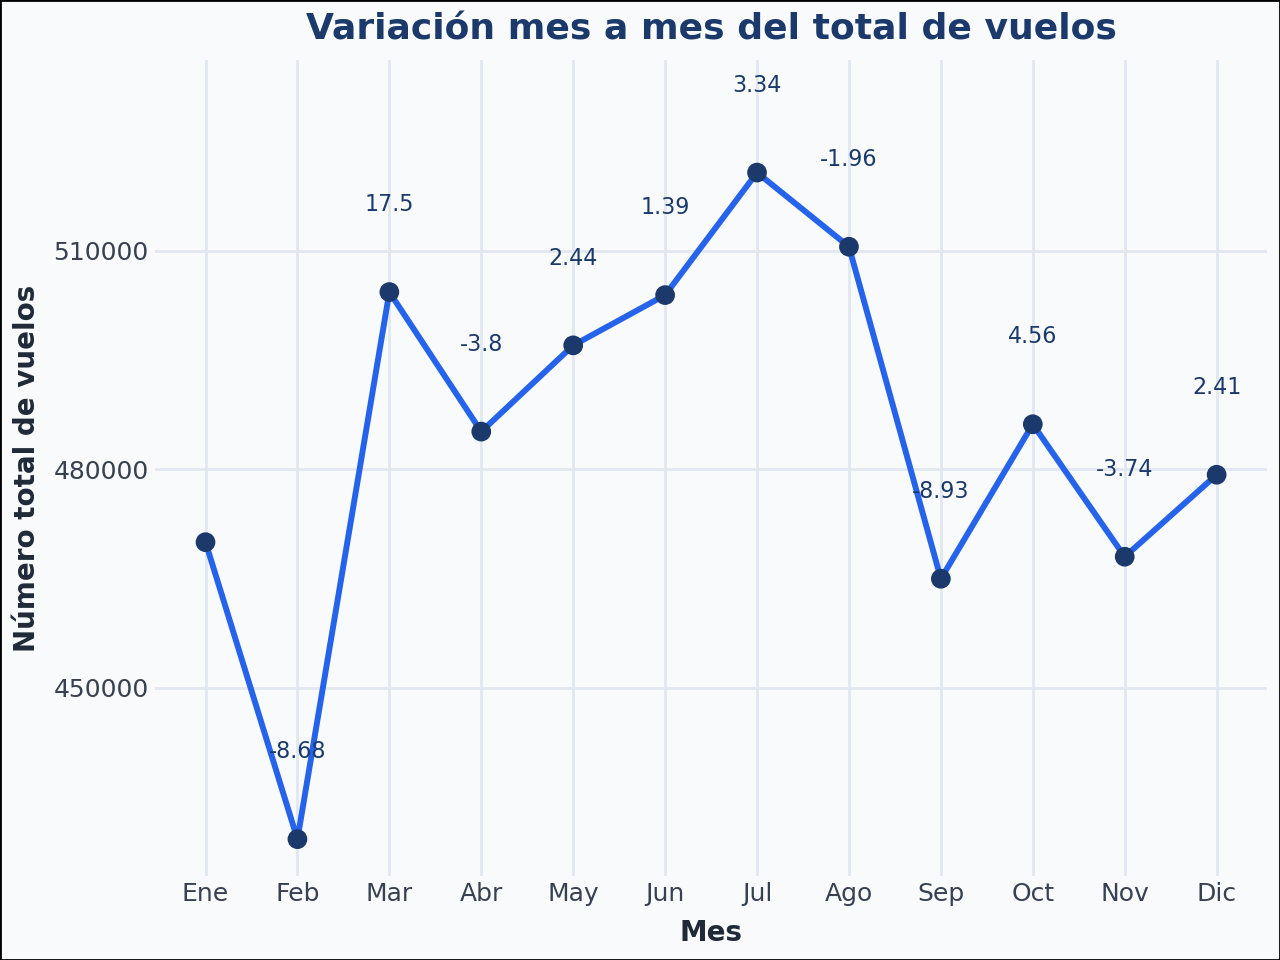

In [17]:
(
    ggplot(df_w2, aes(x="month", y="total_flights"))
    + geom_line(color=PALETTE["blue_mid"], size=1.2)
    + geom_point(color=PALETTE["blue_dark"], size=3)
    + geom_text(
        aes(label="pct_change"),
        va="bottom", 
        nudge_y=max(df_w2["total_flights"])*0.02,
        size=8, 
        color=PALETTE["blue_dark"],
    )
    + scale_x_continuous(
        breaks=list(range(1, 13)), 
        labels=[MONTH_NAMES[i] for i in range(1, 13)]
    )
    + labs(
        title="Variación mes a mes del total de vuelos",
        x="Mes", 
        y="Número total de vuelos",
    )
    + BASE_THEME
)

---
### W3 · Primeros 5 vuelos del día en LAX (1 enero 2015)
**Window function `ROW_NUMBER()` — orden de salida desde LAX el 1 de enero de 2015.**

In [18]:
SQL_W3 = """
WITH ScheduledFlights AS (
    SELECT
        f.flight_number,
        f.airline,
        f.destination_airport,
        f.scheduled_departure,
        ROW_NUMBER() OVER (
            PARTITION BY year, month, day, origin_airport
            ORDER BY scheduled_departure ASC
        ) AS departure_order
    FROM flights f
    WHERE f.origin_airport = 'LAX'
      AND f.year  = 2015
      AND f.month = 1
      AND f.day   = 1
)
SELECT
    s.flight_number,
    s.airline,
    s.destination_airport,
    s.scheduled_departure
FROM ScheduledFlights s
WHERE departure_order <= 5;
"""

with engine.connect() as conn:
    df_w3 = pd.read_sql(text(SQL_W3), conn)

df_w3


,flight_number,airline,destination_airport,scheduled_departure
0,2336,AA,PBI,00:10
1,258,AA,MIA,00:20
2,2013,US,CLT,00:30
3,1434,DL,MSP,00:35
4,115,AA,MIA,01:05


In [19]:
(
    GT(df_w3)
    .tab_header(
        title="Primeros 5 vuelos desde LAX — 1 enero 2015"
    )
    .cols_label(
        flight_number="Vuelo #",
        airline="Aerolínea",
        destination_airport="Destino",
        scheduled_departure="Salida programada",
    )
    .tab_style(
        style=style.text(color="white", weight="bold"),
        locations=loc.title()
    )
    .tab_style(
        style=style.fill(color="#FFD700"),
        locations=loc.body(rows=[0, 2, 4]),
    )
    .tab_style(
        style=style.text(weight="bold", color="FFD700"),
        locations=loc.column_labels(),
    )
    .tab_style(
        style=style.text(weight="bold"),
        locations=loc.body(columns="scheduled_departure"),
    )
    .tab_options(
        table_width="550px",
        heading_background_color="black",
        heading_align="left",
        heading_title_font_size="18px",
        heading_subtitle_font_size="12px",
        column_labels_background_color="#F8FAFC",
        column_labels_border_top_width="2px",
        column_labels_border_top_color=PALETTE["blue_dark"],
        table_body_hlines_color="#E2E8F0",
        table_body_hlines_width="1px",
        table_border_top_style="none",
        table_border_bottom_style="none"
    )
)

GT(_tbl_data=   flight_number airline destination_airport scheduled_departure
0           2336      AA                 PBI               00:10
1            258      AA                 MIA               00:20
2           2013      US                 CLT               00:30
3           1434      DL                 MSP               00:35
4            115      AA                 MIA               01:05, _body=<great_tables._gt_data.Body object at 0x7f920d4b94c0>, _boxhead=Boxhead([ColInfo(var='flight_number', type=<ColInfoTypeEnum.default: 1>, column_label='Vuelo #', column_align='right', column_width=None), ColInfo(var='airline', type=<ColInfoTypeEnum.default: 1>, column_label='Aerolínea', column_align='left', column_width=None), ColInfo(var='destination_airport', type=<ColInfoTypeEnum.default: 1>, column_label='Destino', column_align='left', column_width=None), ColInfo(var='scheduled_departure', type=<ColInfoTypeEnum.default: 1>, column_label='Salida programada', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f920d4b85c0>, _spanners=Spanners([]), _heading=Heading(title='Primeros 5 vuelos desde LAX — 1 enero 2015', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f920d5772f0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f920d5755e0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color='white', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=[0, 2, 4], mask=None), grpname=None, colname='flight_number', rownum=0, colnum=None, styles=[CellStyleFill(color='#FFD700')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 2, 4], mask=None), grpname=None, colname='flight_number', rownum=2, colnum=None, styles=[CellStyleFill(color='#FFD700')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 2, 4], mask=None), grpname=None, colname='flight_number', rownum=4, colnum=None, styles=[CellStyleFill(color='#FFD700')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 2, 4], mask=None), grpname=None, colname='airline', rownum=0, colnum=None, styles=[CellStyleFill(color='#FFD700')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 2, 4], mask=None), grpname=None, colname='airline', rownum=2, colnum=None, styles=[CellStyleFill(color='#FFD700')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 2, 4], mask=None), grpname=None, colname='airline', rownum=4, colnum=None, styles=[CellStyleFill(color='#FFD700')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 2, 4], mask=None), grpname=None, colname='destination_airport', rownum=0, colnum=None, styles=[CellStyleFill(color='#FFD700')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 2, 4], mask=None), grpname=None, colname='destination_airport', rownum=2, colnum=None, styles=[CellStyleFill(color='#FFD700')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 2, 4], mask=None), grpname=None, colname='destination_airport', rownum=4, colnum=None, styles=[CellStyleFill(color='#FFD700')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 2, 4], mask=None), grpname=None, colname='scheduled_departure', rownum=0, colnum=None, styles=[CellStyleFill(color='#FFD700')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 2, 4], mask=None), grpname=None, colname='scheduled_departure', rownum=2, colnum=None, styles=[CellStyleFill(color='#FFD700')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 2, 4], mask=None), grpname=None, colname='scheduled_departure', rownum=4, colnum=None, styles=[CellStyleFill(color='#FFD700')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='flight_number', rownum=None, colnum=None, styles=[CellStyleText(color='FFD700', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch

---
## 2. Regresión lineal

El objetivo de esta sección no es predecir, si no **cuantificar estadísticamente** qué causas de retraso tienen mayor peso sobre `arrival_delay`. Se usa `statsmodels.OLS` para analiza el summary completo: p-values, intervalos de confianza y estadísticos de diagnóstico.

In [20]:
query_gold = """
    SELECT arrival_delay, departure_delay, distance,
           air_system_delay, airline_delay, weather_delay,
           late_aircraft_delay, security_delay
    FROM flights_gold.vuelos_analitica
    WHERE cancelled = 0
      AND departure_delay > 0
      AND arrival_delay > 0
"""

df_gold = wr.athena.read_sql_query(query_gold, database="flights_gold", ctas_approach=False)

---
### EDA breve

In [21]:
desc = df_gold.describe().T[["count", "mean", "std", "min", "50%", "max"]]
desc.columns = ["n", "media", "std", "min", "mediana", "max"]
print(desc.round(2).to_string())

                             n       media         std   min mediana     max
arrival_delay        1508147.0   42.136229   59.474434   1.0    22.0  1971.0
departure_delay      1508147.0   43.265662   59.295255   1.0    24.0  1988.0
distance             1508147.0  824.408871  600.022099  31.0   666.0  4983.0
air_system_delay      950873.0   11.977555   28.777464   0.0     0.0  1134.0
airline_delay         950873.0    21.17772   50.467607   0.0     5.0  1971.0
weather_delay         950873.0    3.245295    21.57593   0.0     0.0  1211.0
late_aircraft_delay   950873.0   26.251593   44.876877   0.0     9.0  1331.0
security_delay        950873.0    0.085162    2.266605   0.0     0.0   573.0


In [22]:
nulls = df_gold.isnull().sum()
print("Nulos por columna:")
print(nulls[nulls > 0] if nulls.any() else "  sin nulos")

FEATURES = [
    "departure_delay", "distance",
    "air_system_delay", "airline_delay", "weather_delay",
    "late_aircraft_delay", "security_delay",
]
TARGET = "arrival_delay"

# Nulos en features de delay = 0 (vuelo no tuvo ese tipo de retraso)
df_model = df_gold[[TARGET] + FEATURES].copy()
df_model[FEATURES] = df_model[FEATURES].fillna(0)
df_model = df_model.dropna(subset=[TARGET])

print(f"\nObservaciones para el modelo: {len(df_model):,}")

Nulos por columna:
air_system_delay       557274
airline_delay          557274
weather_delay          557274
late_aircraft_delay    557274
security_delay         557274
dtype: int64

Observaciones para el modelo: 1,508,147


---
### Ajuste de modelo OLS

In [23]:
y = df_model[TARGET].astype(float)
X = df_model[FEATURES].astype(float)

# Se agrega la columna del intercepto de acuerdo a las especificaciones de statsmodels
X_const = sm.add_constant(X)

model  = sm.OLS(y, X_const).fit()
y_pred = model.fittedvalues
resid  = model.resid

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          arrival_delay   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 5.899e+07
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        05:38:23   Log-Likelihood:            -4.0666e+06
No. Observations:             1508147   AIC:                         8.133e+06
Df Residuals:                 1508139   BIC:                         8.133e+06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   3.2616    

In [24]:
r2   = model.rsquared
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R²   = {r2:.4f}  —  el modelo explica el {r2*100:.1f}% de la varianza en arrival_delay")
print(f"RMSE = {rmse:.2f} minutos")


R²   = 0.9964  —  el modelo explica el 99.6% de la varianza en arrival_delay
RMSE = 3.59 minutos


---
### Viz 1 - Coeficientes con intervalos de confianza del 95%
Un IC que **cruza el cero** indica que el coeficiente no es estadísticamente distinguible de cero con un 95% de confianza.

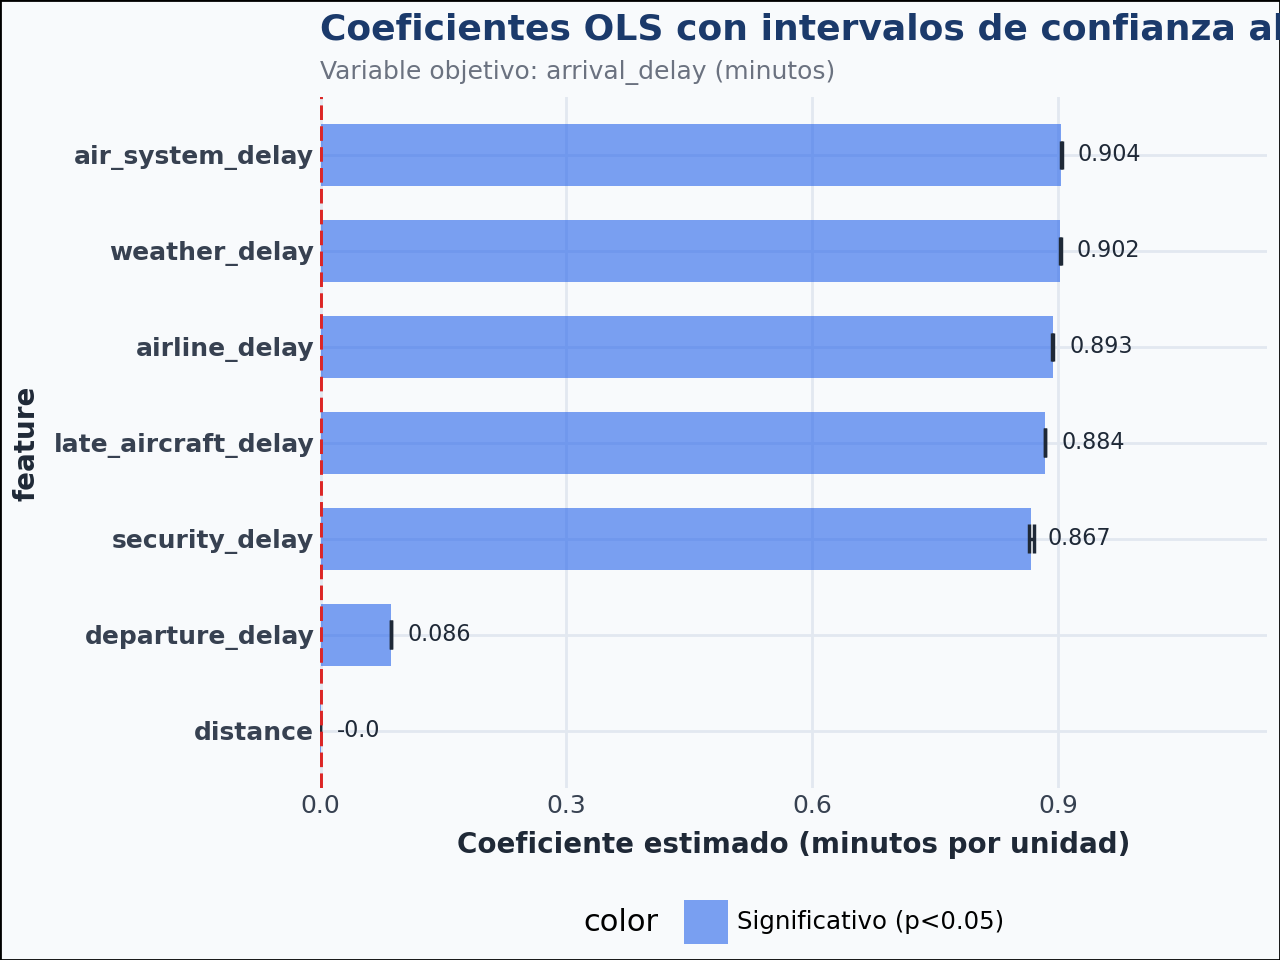

In [25]:
conf_int = model.conf_int()
conf_int.columns = ["ci_low", "ci_high"]

df_coef = pd.DataFrame({
    "feature": model.params.index,
    "coef":    model.params.values,
    "ci_low":  conf_int["ci_low"].values,
    "ci_high": conf_int["ci_high"].values,
    "pvalue":  model.pvalues.values,
}).query("feature != 'const'").copy()

df_coef["significant"] = df_coef["pvalue"] < 0.05
df_coef["color"]       = df_coef["significant"].map(
    {True: "Significativo (p<0.05)", False: "No significativo"}
)
df_coef["coef_label"] = df_coef["coef"].round(3).astype(str)

df_coef = df_coef.sort_values("coef")
df_coef["feature"] = pd.Categorical(
    df_coef["feature"],
    categories=df_coef["feature"].tolist(),
    ordered=True,
)

COLOR_MAP = {
    "Significativo (p<0.05)": PALETTE["blue_mid"],
    "No significativo":       PALETTE["gray"],
}

(
    ggplot(df_coef, aes(x="feature", y="coef", fill="color"))
    + geom_col(width=0.65, show_legend=True, alpha=0.6)
    + geom_errorbar(
        aes(ymin="ci_low", ymax="ci_high"),
        width=0.3, color="#1F2937", size=0.7,
    )
    + geom_hline(yintercept=0, linetype="dashed", color=PALETTE["red"], size=0.8)
    + geom_text(
        aes(label="coef_label"),
        ha="left", nudge_y=0.02, size=8, color="#1F2937",
    )
    + coord_flip()
    + scale_fill_manual(values=COLOR_MAP, name="")
    + scale_y_continuous(expand=(0, 0, 0.25, 0))
    + labs(
        title="Coeficientes OLS con intervalos de confianza al 95%",
        subtitle="Variable objetivo: arrival_delay (minutos)",
        x=None, y="Coeficiente estimado (minutos por unidad)",
    )
    + BASE_THEME
    + theme(axis_text_y=element_text(size=9, face="bold"), legend_position="bottom")
)

---
### Viz 2 — Valores predichos vs. valores reales

La dispersión alrededor de la línea diagonal refleja el error del modelo.

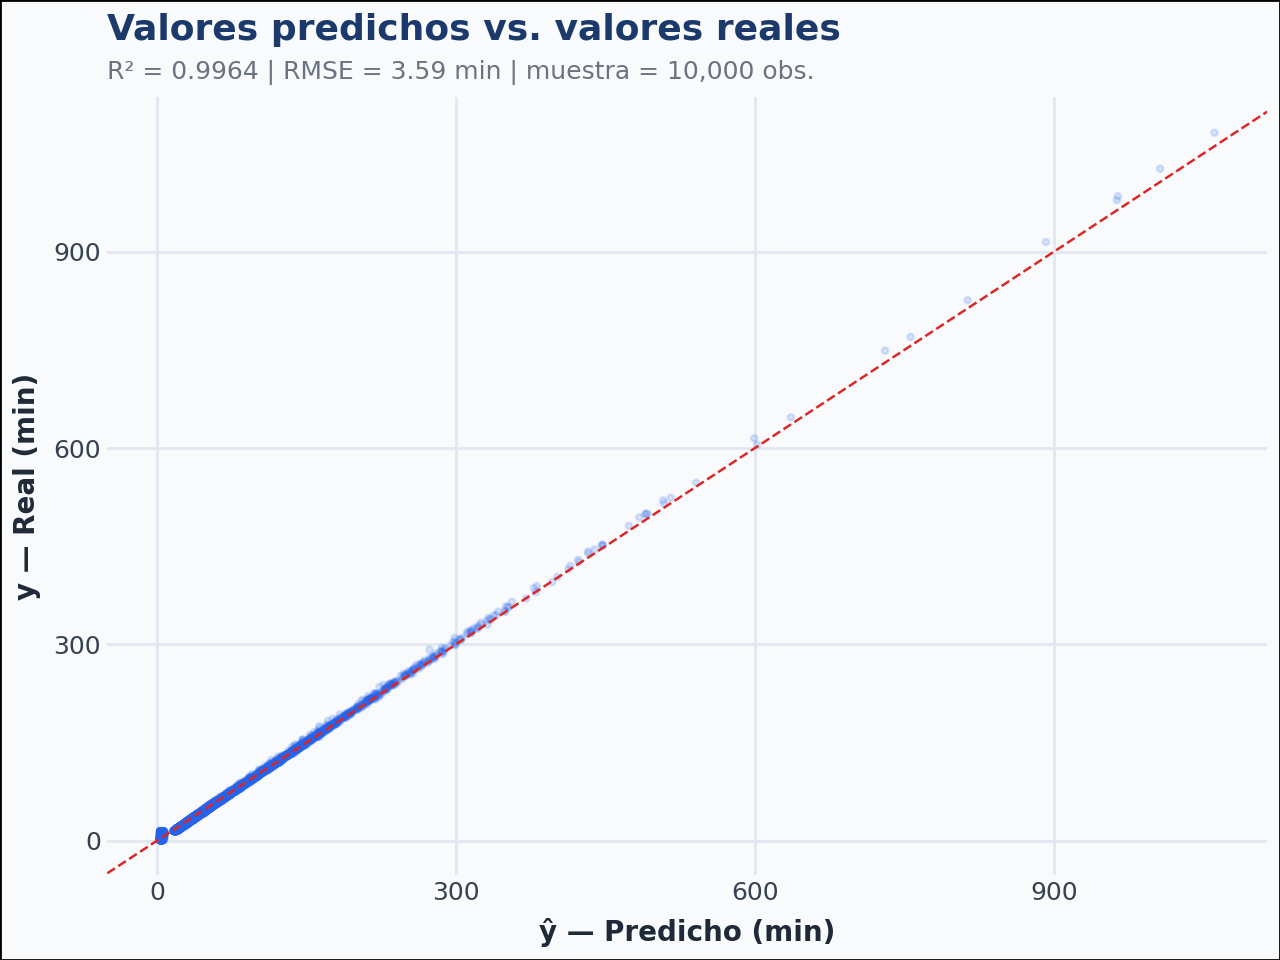

In [26]:
# Muestra aleatoria para no saturar el scatter
rng = np.random.default_rng(42)
idx = rng.choice(len(y), size=min(10_000, len(y)), replace=False)

df_pred = pd.DataFrame({
    "y_real": y.values[idx],
    "y_pred": y_pred.values[idx],
})

(
    ggplot(df_pred, aes(x="y_pred", y="y_real"))
    + geom_point(alpha=0.15, color=PALETTE["blue_mid"], size=0.8)
    + geom_abline(slope=1, intercept=0, color=PALETTE["red"], linetype="dashed", size=.5)
    + labs(
        title="Valores predichos vs. valores reales",
        subtitle=f"R² = {r2:.4f} | RMSE = {rmse:.2f} min | muestra = {len(df_pred):,} obs.",
        x="ŷ — Predicho (min)", y="y — Real (min)",
    )
    + BASE_THEME
)

---
### Viz 3 — Residuos vs. valores predichos

Un modelo bien especificado muestra residuos distribuidos **aleatoriamente alrededor de cero**. Un patrón de embudo indica heterocedasticidad.

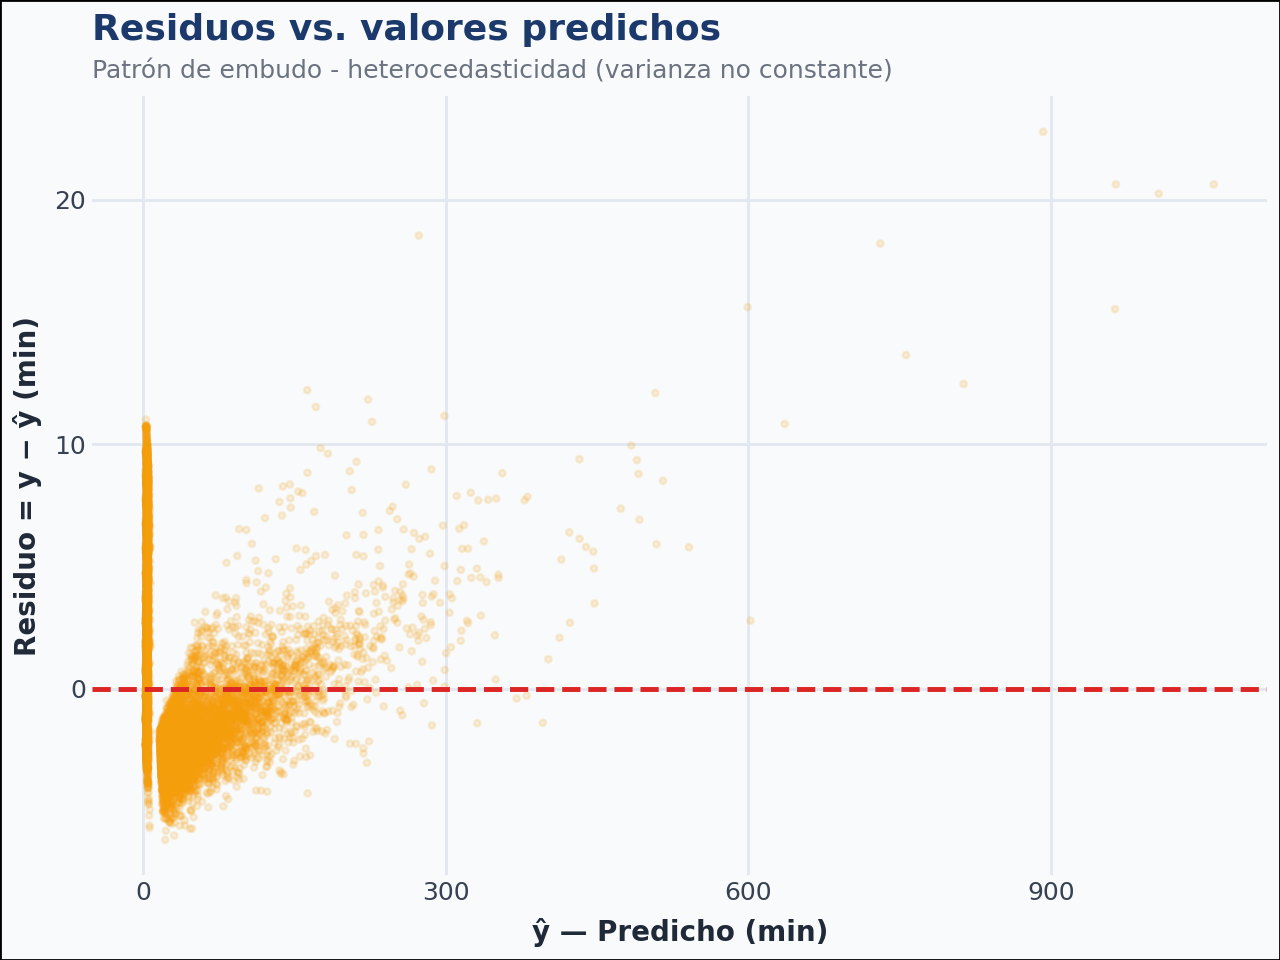

In [27]:
df_resid = pd.DataFrame({
    "y_pred": y_pred.values[idx],
    "resid":  resid.values[idx],
})

(
    ggplot(df_resid, aes(x="y_pred", y="resid"))
    + geom_point(alpha=0.15, color=PALETTE["orange"], size=0.8)
    + geom_hline(yintercept=0, color=PALETTE["red"], linetype="dashed", size=1)
    + labs(
        title="Residuos vs. valores predichos",
        subtitle="Patrón de embudo - heterocedasticidad (varianza no constante)",
        x="ŷ — Predicho (min)", y="Residuo = y − ŷ (min)",
    )
    + BASE_THEME
)


---
### Viz 4 — Q-Q plot de los residuos

Compara los cuantiles de los residuos contra los de una distribución normal teórica. Desviaciones en las **colas** indican distribución asimétrica.

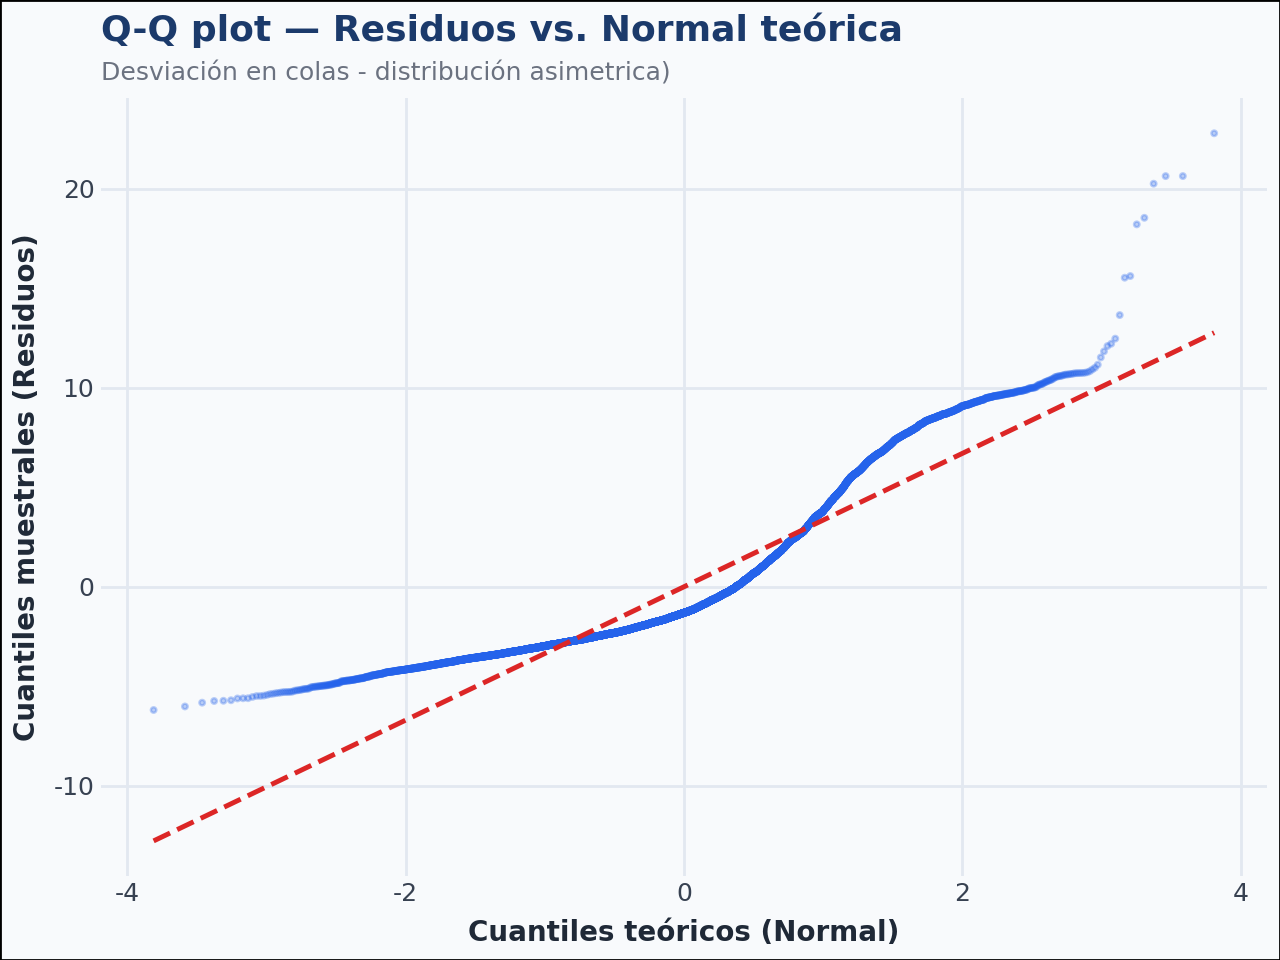

In [28]:
resid_sample = resid.values[idx]
(osm, osr), (slope, intercept, _) = stats.probplot(resid_sample, dist="norm")

df_qq = pd.DataFrame({"theoretical": osm, "sample": osr})
qq_line = pd.DataFrame({
    "theoretical": [float(osm.min()), float(osm.max())],
    "qq_line":     [slope * float(osm.min()) + intercept,
                    slope * float(osm.max()) + intercept],
})

(
    ggplot(df_qq, aes(x="theoretical", y="sample"))
    + geom_point(alpha=0.3, color=PALETTE["blue_mid"], size=0.6)
    + geom_line(
        data=qq_line,
        mapping=aes(x="theoretical", y="qq_line"),
        color=PALETTE["red"], size=1, linetype="dashed",
    )
    + labs(
        title="Q-Q plot — Residuos vs. Normal teórica",
        subtitle="Desviación en colas - distribución asimetrica)",
        x="Cuantiles teóricos (Normal)", y="Cuantiles muestrales (Residuos)",
    )
    + BASE_THEME
)


---
### Métricas e interpretación

**Coeficientes:** `departure_delay` y los cinco componentes operacionales
muestran coeficientes positivos y estadísticamente significativos, cada minuto
de retraso en origen se traslada directamente al retraso de llegada. Caso contrario al componente de distancia que presenta un coeficiente negativo.
La multicolinealidad entre los componentes infla los errores estándar: algunos
intervalos de confianza son acotados para todas las varibales.

**Predichos vs. reales:** los puntos se alinean razonablemente sobre la diagonal
para retrasos moderados, pero el modelo subestima ligeramente los retrasos extremos (cola
derecha), los vuelos con grandes retrasos tienen dinámicas no capturadas por
una relación lineal simple.

**Residuos vs. predichos:** se observa un patrón de embudo: la varianza
de los residuos crece conforme aumentan los valores predichos y evidencia
**heterocedasticidad**, una violación del supuesto OLS de varianza constante.
Los p-values e intervalos de confianza reportados son técnicamente inválidos.

**Q-Q plot:** las colas se desvían de la diagonal, especialmente la derecha,
los residuos tienen distribución asimétrica. Esto es consistente con la
presencia de vuelos atípicos con retrasos extremos que el modelo lineal no
captura adecuadamente.

**Conclusión:** el modelo es útil para cuantificar la **dirección e importancia
relativa** de cada factor, pero sus supuestos formales no se sostienen en datos
operacionales con eventos extremos.

---
## 3. Pronóstico de series de tiempo

### Carga y transformación de datos
Como `flights_silver.flights_monthly` tiene una fila por combinación `(month, airline)`, se necesita agregar al total mensual para obtener una sola serie univariada.

In [29]:
query_silver = """
    SELECT month, SUM(total_flights) AS total_flights
    FROM flights_silver.flights_monthly
    GROUP BY month
    ORDER BY month
"""

df_silver = wr.athena.read_sql_query(query_silver, database="flights_silver", ctas_approach=False)

df_silver.head()

,month,total_flights
0,1,469968
1,2,429191
2,3,504312
3,4,485151
4,5,496993


De acuerdo con la documentación **StatsForecast** requiere tres columnas obligatorias:
- `unique_id` — identificador de la serie (usamos `'total_flights'` para la serie única)
- `ds` — fecha en formato `datetime64` (construimos el primer día de cada mes de 2015)
- `y` — variable objetivo (`total_flights`)

In [31]:
df_silver["ds"] = pd.to_datetime(
    "2015-" + df_silver["month"].astype(str).str.zfill(2) + "-01"
)
df_sf = pd.DataFrame({
    "unique_id": "total_flights",
    "ds": df_silver["ds"],
    "y": df_silver["total_flights"],
})

print(df_sf)

        unique_id         ds       y
0   total_flights 2015-01-01  469968
1   total_flights 2015-02-01  429191
2   total_flights 2015-03-01  504312
3   total_flights 2015-04-01  485151
4   total_flights 2015-05-01  496993
5   total_flights 2015-06-01  503897
6   total_flights 2015-07-01  520718
7   total_flights 2015-08-01  510536
8   total_flights 2015-09-01  464946
9   total_flights 2015-10-01  486165
10  total_flights 2015-11-01  467972
11  total_flights 2015-12-01  479230


---
### Split train-test

- **Train:** enero–septiembre 2015 (9 meses)
- **Test:** octubre–diciembre 2015 (3 meses)

In [32]:
CUTOFF = pd.Timestamp("2015-09-01")

df_train = df_sf[df_sf["ds"] <= CUTOFF].copy()
df_test  = df_sf[df_sf["ds"] >  CUTOFF].copy()

print(f"Train: {len(df_train)} meses  ({df_train['ds'].min().strftime('%b %Y')} – {df_train['ds'].max().strftime('%b %Y')})")
print(f"Test : {len(df_test)}  meses  ({df_test['ds'].min().strftime('%b %Y')} – {df_test['ds'].max().strftime('%b %Y')})")

Train: 9 meses  (Jan 2015 – Sep 2015)
Test : 3  meses  (Oct 2015 – Dec 2015)


---
### Ajuste de los tres modelos con StatsForecast
`season_length=12` le indica a los modelos la periodicidad mensual.

In [33]:
SEASON  = 12
HORIZON = 9
LEVEL   = [90] # intervalos de confianza al 90%

models = [
    AutoETS(season_length=SEASON),
    AutoARIMA(season_length=SEASON),
    AutoTheta(season_length=SEASON),
]

sf = StatsForecast(
    models=models,
    freq="MS",
    n_jobs=-1,
)

sf.fit(df_train)
print("Modelos ajustados")

Modelos ajustados


In [34]:
# Modelo seleccionado automáticamente por cada algoritmo
print("Modelo seleccionado por cada algoritmo:")
print("-" * 45)
for fitted in sf.fitted_:
    for model_obj in fitted:
        name  = type(model_obj).__name__
        inner = getattr(model_obj, "model_", None) or getattr(model_obj, "model", None)
        spec  = str(inner) if inner is not None else "ver summary()"
        print(f"  {name:<12} → {spec}")


Modelo seleccionado por cada algoritmo:
---------------------------------------------
  AutoETS      → {'loglik': -101.67609124578684, 'aic': 209.35218249157367, 'bic': 209.94385622358232, 'aicc': 214.15218249157368, 'mse': 721947057.1865228, 'amse': 633014584.3963304, 'fit': results(x=array([1.00000000e-04, 4.87319922e+05]), fn=203.35218249157367, nit=29, simplex=array([[1.00000000e-04, 4.87223631e+05],
       [1.00000000e-04, 4.87346691e+05],
       [1.00000000e-04, 4.87319922e+05]])), 'residuals': array([-17351.92240399, -58127.18721175,  16999.62550698,  -2163.07445557,
         9679.14185187,  16582.17393769,  33401.51572029,  23216.17556872,
       -22376.14604884]), 'components': 'ANNN', 'm': 1, 'nstate': 1, 'fitted': array([487319.92240399, 487318.18721175, 487312.37449302, 487314.07445557,
       487313.85814813, 487314.82606231, 487316.48427971, 487319.82443128,
       487322.14604884]), 'states': array([[487319.92240399],
       [487318.18721175],
       [487312.37449302],
 

---
### Generación de predicciones

In [35]:
df_fc = sf.predict(h=HORIZON, level=LEVEL)
df_fc = df_fc.reset_index()

# Renombrar columnas de intervalos para facilitar el plotting
df_fc.columns = [c.replace("-", "_") for c in df_fc.columns]

print(f"Pronóstico generado: {len(df_fc)} filas x {len(df_fc.columns)} columnas")
df_fc.head(12)

Pronóstico generado: 9 filas x 12 columnas


,index,unique_id,ds,AutoETS,AutoETS_lo_90,AutoETS_hi_90,AutoARIMA,AutoARIMA_lo_90,AutoARIMA_hi_90,AutoTheta,AutoTheta_lo_90,AutoTheta_hi_90
0,0,total_flights,2015-10-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496523.56250,465489.46875,535667.4375
1,1,total_flights,2015-11-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496524.25000,460775.68750,525887.6250
2,2,total_flights,2015-12-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496524.96875,453725.75000,529276.8750
3,3,total_flights,2016-01-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496525.68750,460986.34375,525810.5000
4,4,total_flights,2016-02-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496526.40625,466634.28125,533010.1250
5,5,total_flights,2016-03-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496527.12500,463863.09375,530507.7500
6,6,total_flights,2016-04-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496527.81250,460121.37500,532280.3125
7,7,total_flights,2016-05-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496528.53125,461351.53125,532693.5625
8,8,total_flights,2016-06-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496529.25000,459872.06250,532316.2500


In [36]:
# Separar los 3 pasos del test set y los 6 pasos futuros
test_dates   = df_test["ds"].values
future_dates = pd.date_range("2016-01-01", periods=6, freq="MS")

df_fc_test   = df_fc[df_fc["ds"].isin(test_dates)].copy()
df_fc_future = df_fc[df_fc["ds"].isin(future_dates)].copy()

print(f"Pronóstico test   : {len(df_fc_test)} filas  ({df_fc_test['ds'].min().strftime('%b %Y')} – {df_fc_test['ds'].max().strftime('%b %Y')})")
print(f"Pronóstico futuro : {len(df_fc_future)} filas  ({df_fc_future['ds'].min().strftime('%b %Y')} – {df_fc_future['ds'].max().strftime('%b %Y')})")

Pronóstico test   : 3 filas  (Oct 2015 – Dec 2015)
Pronóstico futuro : 6 filas  (Jan 2016 – Jun 2016)


---
### Reshape a formato largo para Plotnine

In [37]:
MODEL_NAMES = ["AutoETS", "AutoARIMA", "AutoTheta"]

def fc_to_long(df_forecast, model_names):
    """
    Convierte el DataFrame ancho de StatsForecast a formato largo para plotnine.
    Produce columnas: ds, model, y_hat, lo_90, hi_90.
    """
    rows = []
    for m in model_names:
        col_lo = f"{m}_lo_90"
        col_hi = f"{m}_hi_90"
        tmp = df_forecast[["ds", m]].copy()
        tmp.columns = ["ds", "y_hat"]
        tmp["model"]  = m
        tmp["lo_90"]  = df_forecast[col_lo].values if col_lo in df_forecast else np.nan
        tmp["hi_90"]  = df_forecast[col_hi].values if col_hi in df_forecast else np.nan
        rows.append(tmp)
    return pd.concat(rows, ignore_index=True)

df_fc_test_long   = fc_to_long(df_fc_test,   MODEL_NAMES)
df_fc_future_long = fc_to_long(df_fc_future, MODEL_NAMES)

print(f"Test long  : {df_fc_test_long.shape}")
print(f"Future long: {df_fc_future_long.shape}")
df_fc_test_long.head(6)

Test long  : (9, 5)
Future long: (18, 5)


,ds,y_hat,model,lo_90,hi_90
0,2015-10-01,487319.90625,AutoETS,428025.15625,546614.6250
1,2015-11-01,487319.90625,AutoETS,428025.15625,546614.6250
2,2015-12-01,487319.90625,AutoETS,428025.15625,546614.6250
3,2015-10-01,487301.34375,AutoARIMA,440427.09375,534175.5625
4,2015-11-01,487301.34375,AutoARIMA,440427.09375,534175.5625
5,2015-12-01,487301.34375,AutoARIMA,440427.09375,534175.5625


---
### Viz 1 - Evaluación sobre el test set
Compara los valores reales del test set contra el pronóstico de los tres modelos.
Las bandas sombreadas son los intervalos de confianza al 90%.

In [39]:
# Colores por modelo — consistentes en todas las visualizaciones
MODEL_COLORS = {
    "AutoETS":   PALETTE["blue_mid"],
    "AutoARIMA": PALETTE["green"],
    "AutoTheta": PALETTE["orange"],
    "Real":      PALETTE["blue_dark"],
}

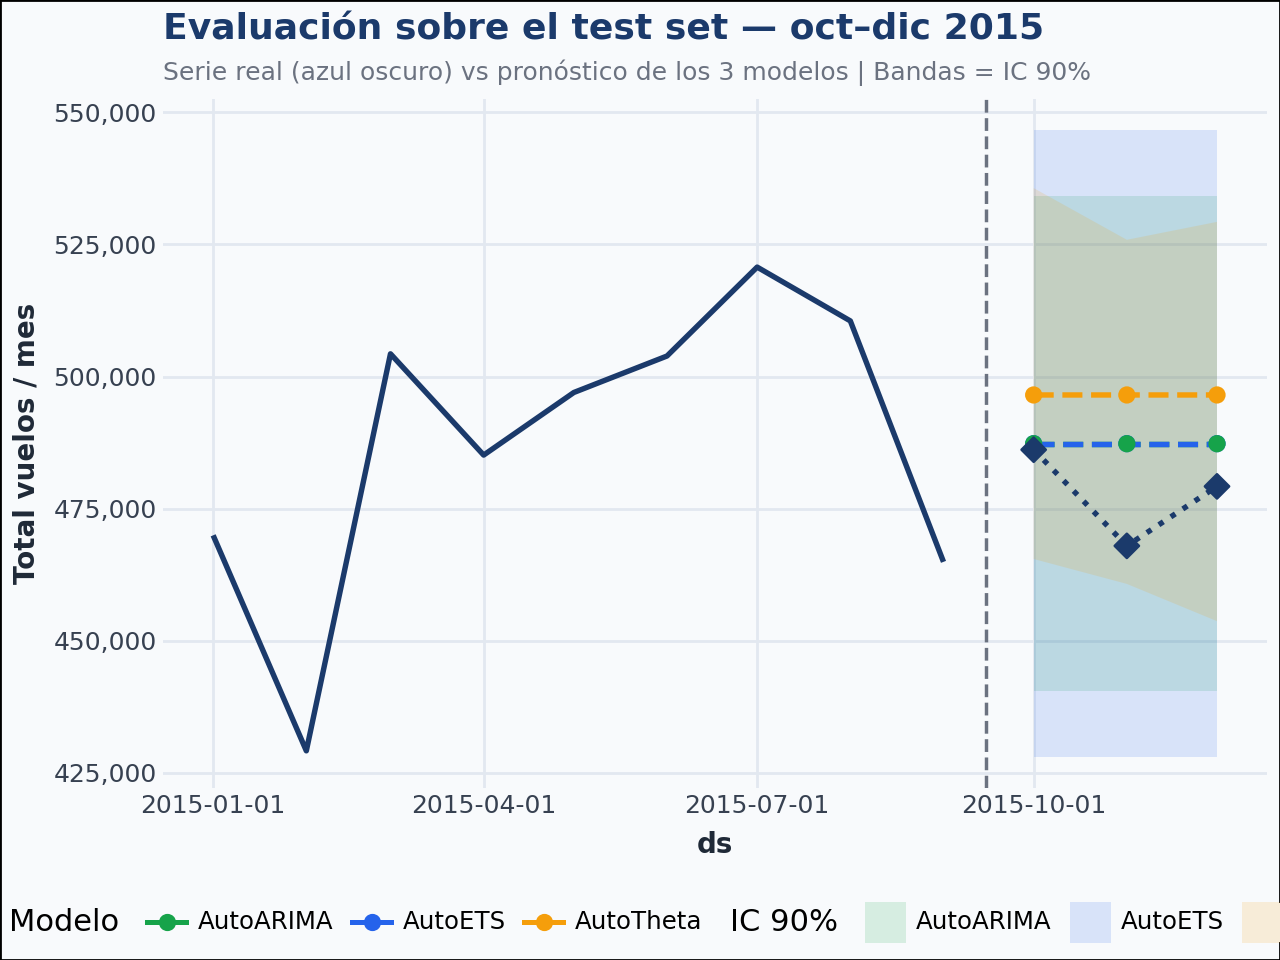

In [40]:
# Serie real completa
df_real = df_sf.copy()
df_real["type"] = df_real["ds"].apply(lambda d: "Train" if d <= CUTOFF else "Test")

# Línea vertical en el corte train/test
cutoff_line = pd.Timestamp("2015-09-15")   # visual — entre sep y oct

(
    ggplot()
    # Banda de confianza por modelo
    + geom_ribbon(
        data=df_fc_test_long,
        mapping=aes(x="ds", ymin="lo_90", ymax="hi_90", fill="model"),
        alpha=0.15,
    )
    # Línea de pronóstico por modelo
    + geom_line(
        data=df_fc_test_long,
        mapping=aes(x="ds", y="y_hat", color="model"),
        size=1.1, linetype="dashed",
    )
    + geom_point(
        data=df_fc_test_long,
        mapping=aes(x="ds", y="y_hat", color="model"),
        size=2.5,
    )
    # Serie real (train)
    + geom_line(
        data=df_real[df_real["type"] == "Train"],
        mapping=aes(x="ds", y="y"),
        color=PALETTE["blue_dark"], size=1.1,
    )
    # Serie real (test)
    + geom_line(
        data=df_real[df_real["type"] == "Test"],
        mapping=aes(x="ds", y="y"),
        color=PALETTE["blue_dark"], size=1.1, linetype="dotted",
    )
    + geom_point(
        data=df_real[df_real["type"] == "Test"],
        mapping=aes(x="ds", y="y"),
        color=PALETTE["blue_dark"], size=3, shape="D",
    )
    # Línea de corte
    + geom_vline(
        xintercept=cutoff_line, linetype="dashed",
        color=PALETTE["gray"], size=0.7,
    )
    + scale_color_manual(values=MODEL_COLORS, name="Modelo")
    + scale_fill_manual(values=MODEL_COLORS,  name="IC 90%")
    + scale_y_continuous(labels=lambda lst: [f"{int(v):,}" for v in lst])
    + labs(
        title="Evaluación sobre el test set — oct–dic 2015",
        subtitle="Serie real (azul oscuro) vs pronóstico de los 3 modelos | Bandas = IC 90%",
        x=None, y="Total vuelos / mes",
    )
    + BASE_THEME
    + theme(legend_position="bottom")
)

---
### Viz 2 - Pronóstico 6 meses hacia adelante
Usamos la serie completa de 2015 (12 meses reales) como contexto y proyectamos los 6 meses siguientes.

In [41]:
# Refitear con la serie completa para el pronóstico futuro
sf_full = StatsForecast(
    models=models,
    freq="MS",
    n_jobs=-1,
)
sf_full.fit(df_sf)

df_fc6 = sf_full.predict(h=6, level=LEVEL).reset_index()
df_fc6.columns = [c.replace("-", "_") for c in df_fc6.columns]

df_fc6_long = fc_to_long(df_fc6, MODEL_NAMES)

print(f"Pronóstico 6 meses: {df_fc6_long.shape}")
df_fc6_long.head()


Pronóstico 6 meses: (18, 5)


,ds,y_hat,model,lo_90,hi_90
0,2016-01-01,484904.03125,AutoETS,436703.375,533104.6875
1,2016-02-01,484904.03125,AutoETS,436703.375,533104.6875
2,2016-03-01,484904.03125,AutoETS,436703.375,533104.6875
3,2016-04-01,484904.03125,AutoETS,436703.375,533104.6875
4,2016-05-01,484904.03125,AutoETS,436703.375,533104.6875


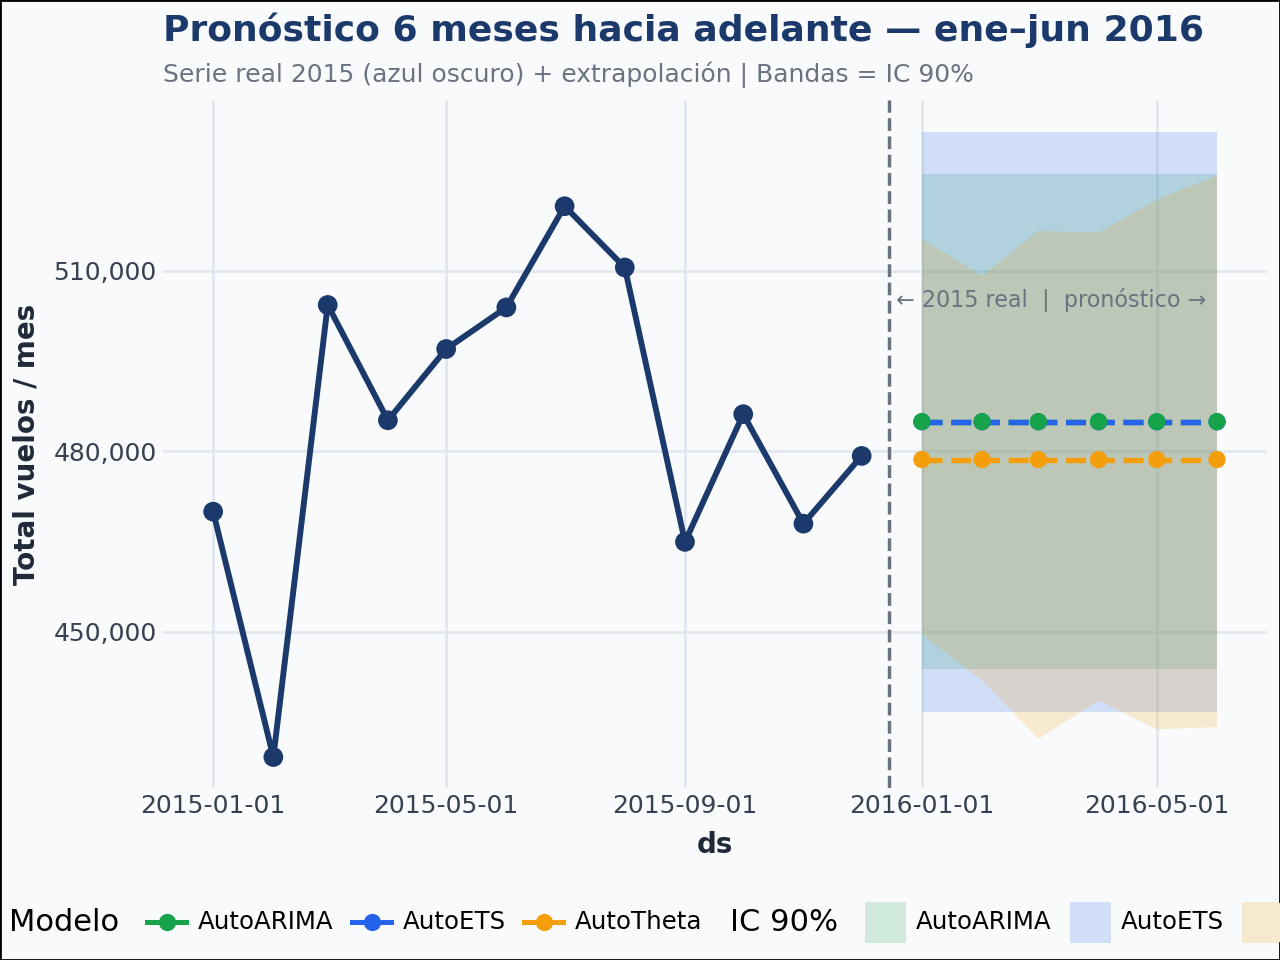

In [44]:
# Línea vertical entre serie real y pronóstico
split_future = pd.Timestamp("2015-12-15")

(
    ggplot()
    # Banda IC pronóstico futuro
    + geom_ribbon(
        data=df_fc6_long,
        mapping=aes(x="ds", ymin="lo_90", ymax="hi_90", fill="model"),
        alpha=0.18,
    )
    # Línea de pronóstico futuro
    + geom_line(
        data=df_fc6_long,
        mapping=aes(x="ds", y="y_hat", color="model"),
        size=1.1, linetype="dashed",
    )
    + geom_point(
        data=df_fc6_long,
        mapping=aes(x="ds", y="y_hat", color="model"),
        size=2.5,
    )
    # Serie real
    + geom_line(
        data=df_sf,
        mapping=aes(x="ds", y="y"),
        color=PALETTE["blue_dark"], size=1.2,
    )
    + geom_point(
        data=df_sf,
        mapping=aes(x="ds", y="y"),
        color=PALETTE["blue_dark"], size=3,
    )
    # Separador real / pronóstico
    + geom_vline(
        xintercept=split_future, linetype="dashed",
        color=PALETTE["gray"], size=0.7,
    )
    + annotate(
        "text", x=split_future, y=df_sf["y"].max() * 0.97,
        label=" ← 2015 real  |  pronóstico →",
        size=8, color=PALETTE["gray"], ha="left",
    )
    + scale_color_manual(values=MODEL_COLORS, name="Modelo")
    + scale_fill_manual(values=MODEL_COLORS,  name="IC 90%")
    + scale_y_continuous(labels=lambda lst: [f"{int(v):,}" for v in lst])
    + labs(
        title="Pronóstico 6 meses hacia adelante — ene–jun 2016",
        subtitle="Serie real 2015 (azul oscuro) + extrapolación | Bandas = IC 90%",
        x=None, y="Total vuelos / mes",
    )
    + BASE_THEME
    + theme(legend_position="bottom")
)


---
### Viz 3 - Comparación de MAE sobre el test set
MAE en unidades de vuelos por mes — cuántos vuelos se equivoca el modelo en promedio en cada uno de los 3 meses del test set.

In [45]:
# Calcular MAE por modelo sobre los 3 meses del test set
test_y = df_test.set_index("ds")["y"]

mae_rows = []
for m in MODEL_NAMES:
    fc_vals = df_fc_test_long[df_fc_test_long["model"] == m].set_index("ds")["y_hat"]
    aligned = test_y.align(fc_vals, join="inner")
    mae = np.abs(aligned[0] - aligned[1]).mean()
    mae_rows.append({"model": m, "mae": round(mae, 1)})

df_mae = pd.DataFrame(mae_rows).sort_values("mae")
df_mae["mae_label"] = df_mae["mae"].apply(lambda v: f"{v:,.0f}")
df_mae["model"] = pd.Categorical(
    df_mae["model"],
    categories=df_mae["model"].tolist(),
    ordered=True,
)

print("MAE por modelo sobre el test set (oct–dic 2015):")
print(df_mae[["model", "mae"]].to_string(index=False))


MAE por modelo sobre el test set (oct–dic 2015):
    model     mae
AutoARIMA  9512.3
  AutoETS  9530.9
AutoTheta 18735.3


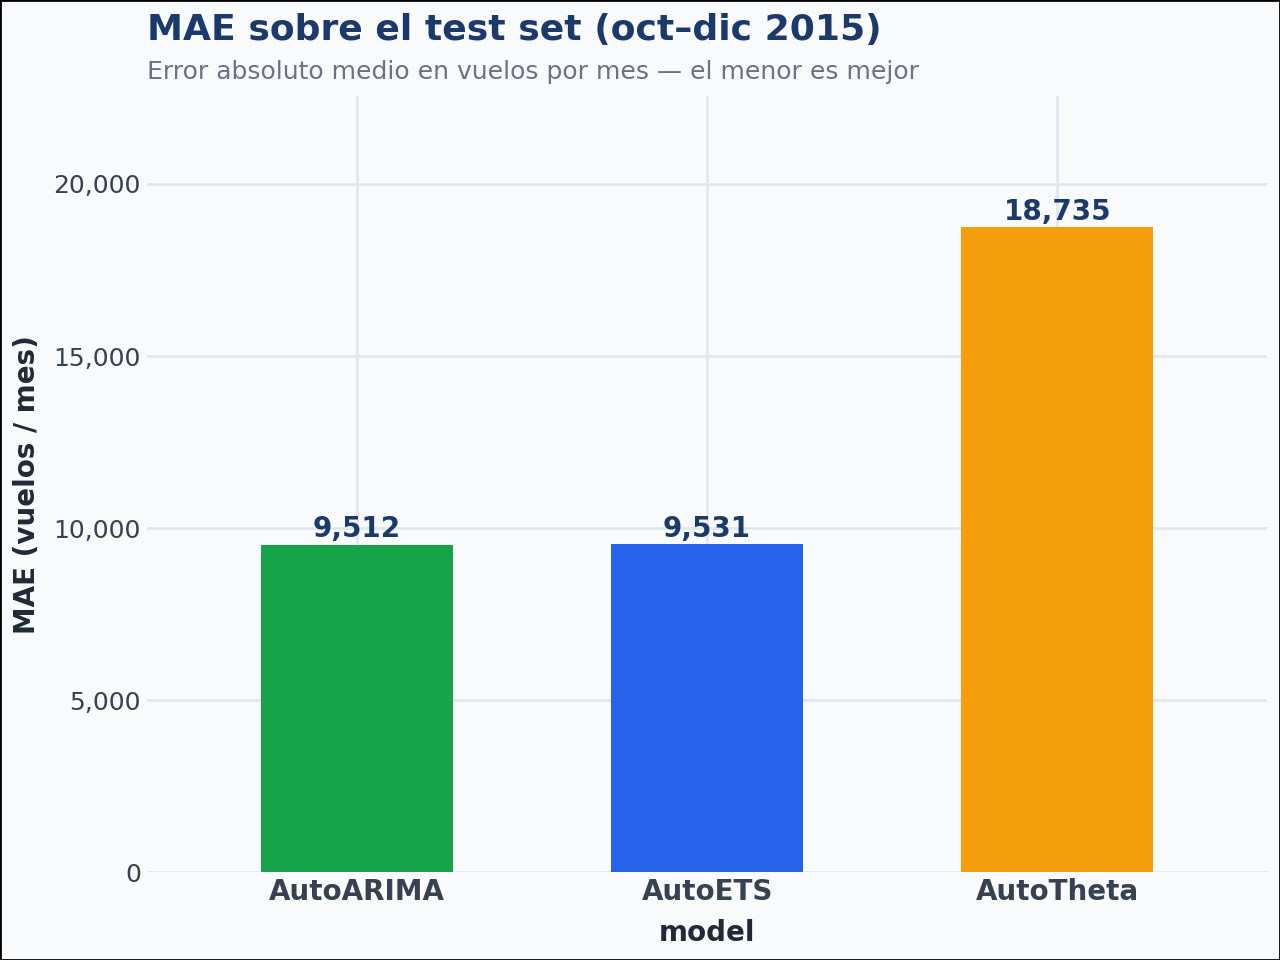

In [47]:
fill_vals = {m: MODEL_COLORS[m] for m in MODEL_NAMES}

(
    ggplot(df_mae, aes(x="model", y="mae", fill="model"))
    + geom_col(width=0.55, show_legend=False)
    + geom_text(
        aes(label="mae_label"),
        va="bottom", nudge_y=50, size=10, color=PALETTE["blue_dark"], fontweight="bold",
    )
    + scale_fill_manual(values=fill_vals)
    + scale_y_continuous(
        labels=lambda lst: [f"{int(v):,}" for v in lst],
        expand=(0, 0, 0.2, 0),
    )
    + labs(
        title="MAE sobre el test set (oct–dic 2015)",
        subtitle="Error absoluto medio en vuelos por mes — el menor es mejor",
        x=None, y="MAE (vuelos / mes)",
    )
    + BASE_THEME
    + theme(axis_text_x=element_text(size=10, face="bold"))
)

---
### Interpretación

Con solo 9 meses de entrenamiento, los tres modelos seleccionan especificaciones no estacionales — lo correcto dado que no existe evidencia estadística de un ciclo anual completo. El modelo **AUTOARIMA**, con menor MAE sobre oct–dic 2015 ofrece la mejor aproximación puntual, pero las **bandas de confianza al 90% son muy amplias**: con un año de datos la incertidumbre del pronóstico crece rápidamente hacia adelante, y los intervalos para ene–jun 2016 capturan un rango de miles de vuelos por mes. Para producir pronósticos confiables con estacionalidad estimada se necesitarían al menos 2–3 años de historia mensual.